In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

MODELS_DIR = r"D:\Programs\supply_chain_ai\backend\app\ml"
DATA_PATH = r"D:\Programs\supply_chain_ai\data\maritime_dataset.csv"

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass balance:")
print(df["late_delivery_risk"].value_counts(normalize=True).round(3))
print(f"\nNull check:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (100000, 26)
Columns: ['shipment_id', 'origin', 'destination', 'distance_km', 'base_time_hrs', 'reliability_score', 'departure_date', 'departure_month', 'departure_year', 'weather_severity_origin', 'weather_severity_route', 'n_restricted_regions', 'n_blocked_regions', 'constraint_penalty', 'passes_suez', 'passes_hormuz', 'passes_malacca', 'passes_bab_el_mandeb', 'passes_cape', 'passes_taiwan_strait', 'passes_south_china_sea', 'is_peak_season', 'is_monsoon_season', 'delay_probability', 'delay_days', 'late_delivery_risk']

Class balance:
late_delivery_risk
1    0.642
0    0.358
Name: proportion, dtype: float64

Null check:
Series([], dtype: int64)


In [5]:
# Cluster the 12 ports into geographic zones
# Features: lat, lon, historical delay rate at that port
port_coords = {
    "Shanghai":   {"lat": 31.23, "lon": 121.47},
    "Singapore":  {"lat":  1.35, "lon": 103.82},
    "Rotterdam":  {"lat": 51.92, "lon":   4.48},
    "Dubai":      {"lat": 25.20, "lon":  55.27},
    "Mumbai":     {"lat": 18.94, "lon":  72.84},
    "Colombo":    {"lat":  6.93, "lon":  79.86},
    "Busan":      {"lat": 35.18, "lon": 129.08},
    "Hong_Kong":  {"lat": 22.32, "lon": 114.17},
    "Hamburg":    {"lat": 53.58, "lon":   9.99},
    "Antwerp":    {"lat": 51.22, "lon":   4.40},
    "Piraeus":    {"lat": 37.95, "lon":  23.64},
    "Karachi":    {"lat": 24.86, "lon":  67.00},
    "Djibouti":   {"lat": 11.57, "lon":  43.15},
    "Port_Klang": {"lat":  3.03, "lon": 101.38},
}

# Compute delay rate per origin port
port_delay = df.groupby("origin")["late_delivery_risk"].mean().reset_index()
port_delay.columns = ["port", "delay_rate"]

# Build port feature matrix
port_features = []
for _, row in port_delay.iterrows():
    port = row["port"]
    if port in port_coords:
        port_features.append({
            "port": port,
            "lat": port_coords[port]["lat"],
            "lon": port_coords[port]["lon"],
            "delay_rate": row["delay_rate"]
        })

port_df = pd.DataFrame(port_features)
print(f"Ports for clustering: {len(port_df)}")
print(port_df.sort_values("delay_rate", ascending=False).round(3))

Ports for clustering: 13
         port    lat     lon  delay_rate
0     Antwerp  51.22    4.40       0.941
10  Rotterdam  51.92    4.48       0.938
7     Karachi  24.86   67.00       0.912
3    Djibouti  11.57   43.15       0.894
12  Singapore   1.35  103.82       0.766
4       Dubai  25.20   55.27       0.692
11   Shanghai  31.23  121.47       0.657
2     Colombo   6.93   79.86       0.627
1       Busan  35.18  129.08       0.624
8      Mumbai  18.94   72.84       0.507
6   Hong_Kong  22.32  114.17       0.353
9     Piraeus  37.95   23.64       0.280
5     Hamburg  53.58    9.99       0.250


In [6]:
# Scale and cluster
X_ports        = port_df[["lat", "lon", "delay_rate"]]
scaler_kmeans  = StandardScaler()
X_ports_scaled = scaler_kmeans.fit_transform(X_ports)

# Find optimal K
wcss = []
for k in range(2, min(len(port_df), 10)):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_ports_scaled)
    wcss.append(km.inertia_)

knee = KneeLocator(range(2, min(len(port_df), 10)),wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

print(f"\nOptimal K: {optimal_k}")


Optimal K: 4


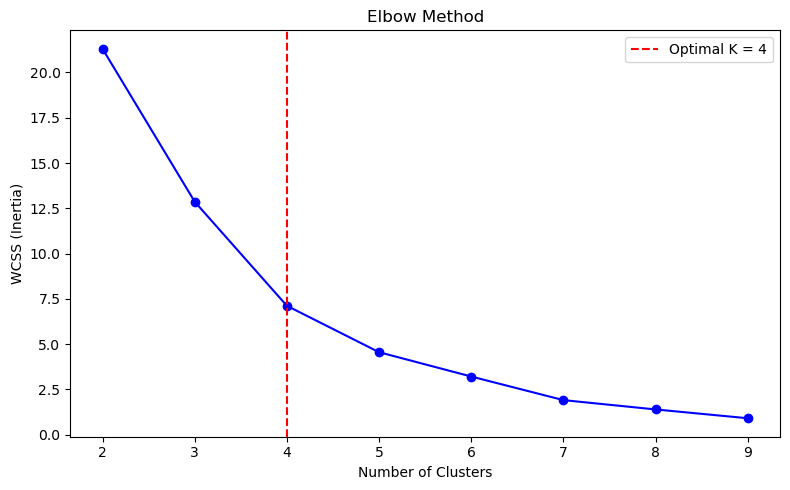

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, min(len(port_df), 10)), wcss, marker="o",color="b")
plt.axvline(x=optimal_k, color="r", linestyle="--", label=f"Optimal K = {optimal_k}")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Inertia)")
plt.tight_layout()
plt.legend()
plt.show()

In [8]:
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
port_df["zone_id"] = kmeans_model.fit_predict(X_ports_scaled)
zone_risk = port_df.groupby("zone_id")["delay_rate"].mean()
port_df["zone_risk_score"] = port_df["zone_id"].map(zone_risk)

print("\nZone summary:")
print(port_df.groupby("zone_id").agg(
    ports      = ("port", list),
    zone_risk  = ("zone_risk_score", "first")
).round(3))


Zone summary:
                                                     ports  zone_risk
zone_id                                                              
0        [Colombo, Djibouti, Dubai, Karachi, Mumbai, Si...      0.733
1                                     [Antwerp, Rotterdam]      0.939
2                             [Busan, Hong_Kong, Shanghai]      0.545
3                                       [Hamburg, Piraeus]      0.265


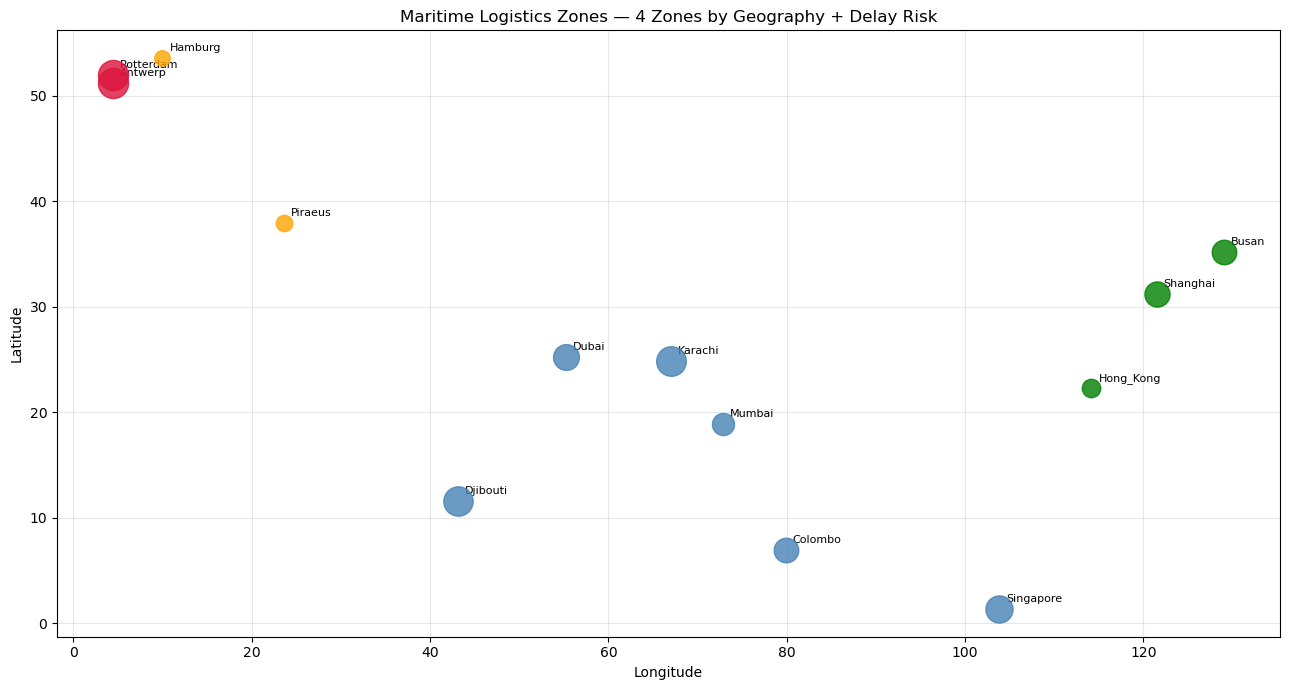

In [9]:
plt.figure(figsize=(13, 7))
colors = ["steelblue", "crimson", "green", "orange", "purple"]

for _, row in port_df.iterrows():
    color = colors[int(row["zone_id"]) % len(colors)]
    plt.scatter(row["lon"], row["lat"], 
                c=color, s=row["delay_rate"]*500,
                alpha=0.8, zorder=5)
    plt.annotate(row["port"], (row["lon"], row["lat"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.title(f"Maritime Logistics Zones — {optimal_k} Zones by Geography + Delay Risk")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Create port → zone lookup
port_zone_lookup = port_df[["port", "zone_id", "zone_risk_score"]].copy()

# Map origin port to zone
df = pd.merge(
    df,
    port_zone_lookup.rename(columns={"port": "origin"}),
    on="origin",
    how="left"
)

print(f"Zone assigned: {df['zone_id'].notna().sum()} / {len(df)}")
print(f"Zone distribution:")
print(df["zone_id"].value_counts().sort_index())

Zone assigned: 100000 / 100000
Zone distribution:
zone_id
0    52493
1     5924
2    36378
3     5205
Name: count, dtype: int64


## Maritime Anomaly Definition:

In [11]:
# A shipment is anomalous when its actual risk conditions are significantly worse than the historical average for that route.

# 1: Compute per-route historical averages
route_baseline = df.groupby(["origin", "destination"]).agg(
    avg_weather = ("weather_severity_route", "mean"),
    avg_constraint = ("constraint_penalty", "mean"),
    avg_delay_rate = ("late_delivery_risk", "mean"),
    std_weather = ("weather_severity_route", "std"),
    std_constraint = ("constraint_penalty", "std"),
).reset_index()

route_baseline["std_weather"] = route_baseline["std_weather"].fillna(0.1)
route_baseline["std_constraint"] = route_baseline["std_constraint"].fillna(0.01)

df = pd.merge(df, route_baseline, on=["origin", "destination"], how="left")

In [12]:
# 2: Compute z-scores relative to route baseline
df["weather_z"]    = ((df["weather_severity_route"] - df["avg_weather"])
                       / df["std_weather"].clip(lower=0.1))
df["constraint_z"] = ((df["constraint_penalty"] - df["avg_constraint"])
                       / df["std_constraint"].clip(lower=0.01))

In [13]:
# 3: Composite anomaly score
df["anomaly_score"] = (df["weather_z"] * 0.5 + df["constraint_z"] * 0.5)

In [14]:
# 4: Flag top 5% as anomalous
threshold = df["anomaly_score"].quantile(0.95)
df["anomaly_flag"] = (df["anomaly_score"] >= threshold).astype(int)

n_anomalies = df["anomaly_flag"].sum()
print(f"Anomalies flagged: {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)")

print(f"\nDelay rate by anomaly flag:")
print(df.groupby("anomaly_flag")["late_delivery_risk"].mean().round(3))

print(f"\nAnomaly group feature averages:")
cols_check = ["weather_severity_route", "constraint_penalty",
              "n_restricted_regions", "anomaly_score", "late_delivery_risk"]
print(df.groupby("anomaly_flag")[cols_check].mean().round(3))

Anomalies flagged: 5000 / 100000 (5.0%)

Delay rate by anomaly flag:
anomaly_flag
0    0.632
1    0.838
Name: late_delivery_risk, dtype: float64

Anomaly group feature averages:
              weather_severity_route  constraint_penalty  \
anomaly_flag                                               
0                              0.548               0.520   
1                              1.449               0.725   

              n_restricted_regions  anomaly_score  late_delivery_risk  
anomaly_flag                                                           
0                            0.479         -0.070               0.632  
1                            0.532          1.328               0.838  


In [15]:
# Clean up baseline columns
df.drop(columns=["avg_weather", "avg_constraint", "avg_delay_rate","std_weather", "std_constraint",
                 "weather_z", "constraint_z", "anomaly_score"],inplace=True)

In [16]:
os.makedirs(MODELS_DIR, exist_ok=True)

# K-Means zone clustering models
joblib.dump(kmeans_model, os.path.join(MODELS_DIR, "kmeans_model.joblib"))
joblib.dump(scaler_kmeans, os.path.join(MODELS_DIR, "kmeans_scaler.joblib"))

# Port zone lookup
port_zone_lookup.to_csv(
    os.path.join(MODELS_DIR, "port_zone_lookup.csv"), index=False
)

route_baseline_save = df.groupby(["origin", "destination"]).agg(
    avg_weather    = ("weather_severity_route", "mean"),
    std_weather    = ("weather_severity_route", "std"),
    avg_constraint = ("constraint_penalty", "mean"),
    std_constraint = ("constraint_penalty", "std"),
).reset_index()

route_baseline_save["std_weather"] = route_baseline_save["std_weather"].fillna(0.1)
route_baseline_save["std_constraint"] = route_baseline_save["std_constraint"].fillna(0.01)

route_baseline_save.to_csv(
    os.path.join(MODELS_DIR, "route_anomaly_baseline.csv"), index=False
)

enriched_path = r"D:\Programs\supply_chain_ai\data\maritime_enriched.csv"
df.to_csv(enriched_path, index=False)

print("Files saved:")
for fname in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, fname))
    print(f"  {fname:45s}  {size/1024:6.1f} KB")

print(f"Shape: {df.shape}")

Files saved:
  __pycache__                                       0.0 KB
  explainer.py                                      4.0 KB
  feature_cols.json                                 0.5 KB
  features.py                                       6.0 KB
  kmeans_model.joblib                               0.9 KB
  kmeans_scaler.joblib                              0.9 KB
  loader.py                                         2.0 KB
  model_meta.json                                   0.9 KB
  port_zone_lookup.csv                              0.4 KB
  predictor.py                                      1.6 KB
  route_anomaly_baseline.csv                        2.0 KB
  shap_explainer.joblib                          6624.8 KB
  xgb_classifier.joblib                          1948.5 KB
  xgb_classifier.ubj                             1945.1 KB
  xgb_regressor.joblib                           2162.3 KB
  xgb_regressor.ubj                              2159.0 KB
Shape: (100000, 29)


In [18]:
joblib.dump(kmeans_model,  os.path.join(MODELS_DIR, "kmeans_model.joblib"))
joblib.dump(scaler_kmeans, os.path.join(MODELS_DIR, "kmeans_scaler.joblib"))
print("Resaved on sklearn 1.8.0")

Resaved on sklearn 1.8.0
